
# Flow Matching in Pixel Space on CelebA

This notebook is a simple educational implementation of **flow matching** in **pixel space**.
We will:

1. Load the **CelebA** dataset with `torchvision`
2. Use a Unet (available at `diffusers.UNet2DModel`) as the velocity model
3. Train with the simple **flow matching** objective
4. Sample by integrating an ODE with Euler steps
5. End with two conditioning examples:
    - **conditional training**
    - **classifier guidance**




In [1]:
# If needed:
!pip install --no-cache-dir diffusers torch==2.5.1 torchvision==0.20.1 torchaudio==2.5.1 --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 326.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 240.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 272.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 332.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 390.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 316.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 330.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 291.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 349.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 359.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 283.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196

In [2]:
import math
import os
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as T
from torchvision.utils import make_grid

import tqdm

import matplotlib.pyplot as plt

from diffusers import UNet2DModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


device: cuda


In [3]:
torch.manual_seed(0)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(0)

In [4]:
torch.rand_like(torch.rand(3, device="cuda"))

tensor([0.9722, 0.7910, 0.4690], device='cuda:0')

In [5]:
@dataclass
class Config:
    image_size: int = 64
    batch_size: int = 64
    num_workers: int = 4
    lr: float = 2e-4
    wd: float = 1e-4
    epochs: int = 15
    sample_steps: int = 100
    attribute_name: str = "Eyeglasses"

cfg = Config()
cfg


Config(image_size=64, batch_size=64, num_workers=4, lr=0.0002, wd=0.0001, epochs=15, sample_steps=100, attribute_name='Eyeglasses')

## Dataset: CelebA

Download the dataset from my Google Drive

In [6]:
file_id = "1X5AIfVSbroK4g3NQfrMtpUMFawBjxlIB"
!gdown {file_id}
!unzip -u celeba_data.zip > /dev/null

Downloading...
From (original): https://drive.google.com/uc?id=1X5AIfVSbroK4g3NQfrMtpUMFawBjxlIB
From (redirected): https://drive.google.com/uc?id=1X5AIfVSbroK4g3NQfrMtpUMFawBjxlIB&confirm=t&uuid=1cb82ab7-1ee3-4770-b470-e28260b7e3a7
To: /kaggle/working/celeba_data.zip
100%|██████████████████████████████████████| 2.88G/2.88G [02:37<00:00, 18.3MB/s]


In [7]:
train_transform = T.Compose([
    T.CenterCrop(178),
    T.Resize((cfg.image_size, cfg.image_size)),

    # --- augmentations ---
    T.RandomHorizontalFlip(p=0.5),
    T.RandomAffine(
        degrees=0,
        translate=(0.02, 0.02),   # small shifts
        scale=(0.98, 1.02)        # tiny zoom
    ),
    T.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1,
        hue=0.02
    ),

    T.ToTensor(),
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

val_transform = T.Compose([
    T.CenterCrop(178),
    T.Resize((cfg.image_size, cfg.image_size)),
    T.ToTensor(),
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

train_ds = torchvision.datasets.CelebA(
    root='./celeba_data',
    split="train",
    target_type="attr",
    transform=train_transform,
    download=False,
)

val_ds = torchvision.datasets.CelebA(
    root='./celeba_data',
    split="valid",
    target_type="attr",
    transform=val_transform,
    download=False,
)

train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=True,
    drop_last=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=True,
    drop_last=False,
)

print("train size:", len(train_ds))
print("val size:", len(val_ds))


train size: 162770
val size: 19867


## Dataset attributes

In [8]:

attr_names = train_ds.attr_names
print(attr_names[:10])



['5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair', 'Blond_Hair']


In [9]:
def denorm(x):
    return x.clamp(-1, 1).add(1).div(2)

def show_batch(x, n=16, title=None):
    x = denorm(x[:n].cpu())
    grid = make_grid(x, nrow=int(math.sqrt(n)))
    plt.figure(figsize=(6, 6))
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis("off")
    if title is not None:
        plt.title(title)
    plt.show()

images: torch.Size([64, 3, 64, 64])
attrs: torch.Size([64, 40])


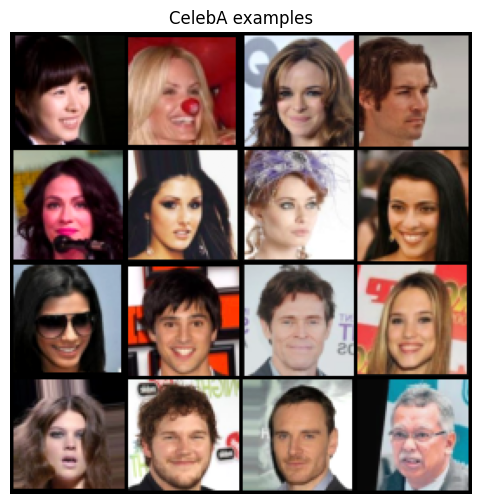

In [10]:
xb, attrb = next(iter(train_loader))
print("images:", xb.shape)
print("attrs:", attrb.shape)
show_batch(xb, title="CelebA examples")


## Model
We are going to use a UNet implemented in `diffusers.UNet2DModel` This UNet is a bit special because in addition to the 3 RGB channels, the input is also a the current time-step (a number between 0 to 1). Internally, that number gets converted into an embedding vector, and the embedding vectors gets added to the output of each of the blocks.



In [11]:
class FlowUNet(nn.Module):
    def __init__(self, image_size=64, in_channels=3, out_channels=3):
        super().__init__()
        self.net = UNet2DModel(
            sample_size=image_size,
            in_channels=in_channels,
            out_channels=out_channels,
            layers_per_block=2,
            block_out_channels=(64, 128, 128, 256),
            down_block_types=(
                "DownBlock2D",
                "DownBlock2D",
                "DownBlock2D",
                "AttnDownBlock2D",
            ),
            up_block_types=(
                "AttnUpBlock2D",
                "UpBlock2D",
                "UpBlock2D",
                "UpBlock2D",
            ),
        )

    def forward(self, x, t):
        # diffusers UNet accepts timesteps as ints/floats/tensors
        # and returns an object with .sample
        return self.net(x, t).sample


## Flow matching loss

We use the straight-line path:

$$
x_t = (1-t)x_0 + t x_1
$$

with target velocity:

$$
u_t = x_1 - x_0
$$

and train the model to predict that velocity.


In [12]:
def flow_matching_loss(model, x1):
    b = x1.shape[0]
    x0 = torch.randn_like(x1)  #The input at time=0 is just random noise

    t = torch.rand(b, device=x1.device) #t is the time step, a number between 0
                                        # and 1 for each batch element

    xt = (1.0 - t[:, None, None, None]) * x0 + t[:, None, None, None] * x1
    target = x1 - x0

    pred = model(xt, t)
    loss = F.mse_loss(pred, target)
    return loss

In [13]:
model = FlowUNet(image_size=cfg.image_size).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.wd)

num_params = sum(p.numel() for p in model.parameters())
print(f"parameters: {num_params/1e6:.2f}M")

parameters: 18.20M


In [14]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    running = 0.0

    for x, _ in tqdm.tqdm(loader, desc="Train"):
        x = x.to(device, non_blocking=True)
        loss = flow_matching_loss(model, x)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        running += loss.item()

    return running / len(loader)

@torch.no_grad()
def eval_one_epoch(model, loader, device):
    model.eval()
    running = 0.0

    for x, _ in tqdm.tqdm(loader,  desc="Validation"):
        x = x.to(device, non_blocking=True)
        loss = flow_matching_loss(model, x)
        running += loss.item()

    return running / len(loader)


Validation: 100%|██████████| 311/311 [00:36<00:00,  8.62it/s]


epoch 01 | train 0.1688 | val 0.1341


Validation: 100%|██████████| 311/311 [00:36<00:00,  8.64it/s]


epoch 02 | train 0.1331 | val 0.1287


Validation: 100%|██████████| 311/311 [00:35<00:00,  8.67it/s]


...

epoch 13 | train 0.1159 | val 0.1167


Validation: 100%|██████████| 311/311 [00:35<00:00,  8.70it/s]


epoch 14 | train 0.1157 | val 0.1145


Validation: 100%|██████████| 311/311 [00:35<00:00,  8.66it/s]


epoch 15 | train 0.1146 | val 0.1137


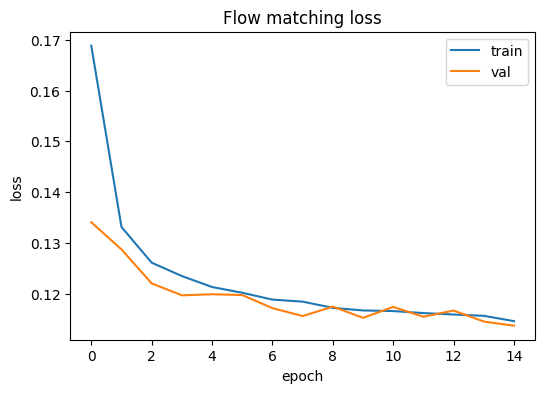

In [15]:
train_losses = []
val_losses = []

for epoch in range(cfg.epochs):
    tr = train_one_epoch(model, train_loader, optimizer, device)
    va = eval_one_epoch(model, val_loader, device)
    train_losses.append(tr)
    val_losses.append(va)
    print(f"epoch {epoch+1:02d} | train {tr:.4f} | val {va:.4f}")


plt.figure(figsize=(6, 4))
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.title("Flow matching loss")
plt.show()


In [16]:
torch.save(model.state_dict(), "flow_model_1.pt")


## Sampling with Euler integration

After training, we solve

$$
 \frac{dx}{dt} = v_\theta(x,t), \qquad x(0)\sim \mathcal N(0,I)
$$

Using Euler integration
$$
x_{t+1}=x_{t} + v_\theta(x,t) \cdot \Delta t
$$


In [17]:
@torch.no_grad()
def sample_euler(model, n_samples=16, steps=100, size=64, device="cuda"):
    model.eval()
    x = torch.randn(n_samples, 3, size, size, device=device)
    dt = 1.0 / steps

    for i in range(steps):
        t = torch.full((n_samples,), i / steps, device=device)
        v = model(x, t)
        x = x + dt * v

    return x.clamp(-1, 1)

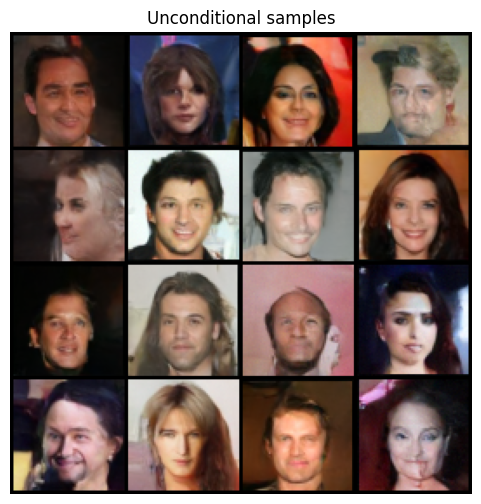

In [18]:
samples = sample_euler(
    model,
    n_samples=16,
    steps=cfg.sample_steps,
    size=cfg.image_size,
    device=device,
)
show_batch(samples, title="Unconditional samples")

---
# Conditioning

We now show two conditioning strategies:

1. conditional training
2. classifier guidance. It does not require re-training the generative model

In [19]:
attr_to_idx = {name: i for i, name in enumerate(attr_names)}
attr_idx = attr_to_idx[cfg.attribute_name]
print(cfg.attribute_name, "index =", attr_idx)

Eyeglasses index = 15


## Part A: Conditional training

Since `UNet2DModel` is not a general-purpose conditional U-Net interface for arbitrary label embeddings in the same way our handwritten model was, the cleanest educational trick is to **append an extra conditioning channel**.

For a binary attribute y in {0,1}, we create a constant image channel filled with y and concatenate it to the RGB image.

So the model input becomes 4 channels instead of 3:
 - 3 image channels
 - 1 conditioning channel


In [20]:
class ConditionalFlowUNet(nn.Module):
    def __init__(self, image_size=64):
        super().__init__()
        self.net = UNet2DModel(
            sample_size=image_size,
            in_channels=4,   # RGB + one condition channel
            out_channels=3,  # still predict velocity in RGB space
            layers_per_block=2,
            block_out_channels=(64, 128, 128, 256),
            down_block_types=(
                "DownBlock2D",
                "DownBlock2D",
                "DownBlock2D",
                "AttnDownBlock2D",
            ),
            up_block_types=(
                "AttnUpBlock2D",
                "UpBlock2D",
                "UpBlock2D",
                "UpBlock2D",
            ),
        )

    def forward(self, x, t, y):
        # y: [B] in {0,1}
        y_img = y.float()[:, None, None, None].expand(-1, 1, x.shape[2], x.shape[3])
        x_in = torch.cat([x, y_img], dim=1)
        return self.net(x_in, t).sample


In [21]:
cond_model = ConditionalFlowUNet(image_size=cfg.image_size).to(device)
cond_optimizer = torch.optim.AdamW(cond_model.parameters(), lr=cfg.lr, weight_decay=cfg.wd)

In [22]:
def conditional_flow_matching_loss(model, x1, y):
    b = x1.shape[0]
    x0 = torch.randn_like(x1)
    t = torch.rand(b, device=x1.device)

    xt = (1.0 - t[:, None, None, None]) * x0 + t[:, None, None, None] * x1
    target = x1 - x0

    pred = model(xt, t, y)
    loss = F.mse_loss(pred, target)
    return loss

In [23]:
def train_one_epoch_cond(model, loader, optimizer, device, attr_idx):
    model.train()
    running = 0.0

    for x, attrs in tqdm.tqdm(loader, desc="Train"):
        x = x.to(device, non_blocking=True)
        y = ((attrs[:, attr_idx] + 1) // 2).to(device)  # CelebA: {-1, +1} -> {0,1}

        loss = conditional_flow_matching_loss(model, x, y)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        running += loss.item()

    return running / len(loader)

In [24]:
@torch.no_grad()
def eval_one_epoch_cond(model, loader, device, attr_idx):
    model.eval()
    running = 0.0

    for x, attrs in tqdm.tqdm(loader, desc="Val"):
        x = x.to(device, non_blocking=True)
        y = ((attrs[:, attr_idx] + 1) // 2).to(device)  # CelebA: {-1, +1} -> {0,1}

        loss = conditional_flow_matching_loss(model, x, y)
        running += loss.item()

    return running / len(loader)

In [25]:
cond_train_losses = []
cond_val_losses = []

cond_epochs = 15
for epoch in range(cond_epochs):
    tr = train_one_epoch_cond(cond_model, train_loader, cond_optimizer, device, attr_idx)
    va = eval_one_epoch_cond(cond_model, val_loader, device, attr_idx)

    cond_train_losses.append(tr)
    cond_val_losses.append(va)

    print(f"[conditional] epoch {epoch+1:02d} | train {tr:.4f} | val {va:.4f}")

Val: 100%|██████████| 311/311 [00:35<00:00,  8.66it/s]


[conditional] epoch 01 | train 0.1690 | val 0.1349


Val: 100%|██████████| 311/311 [00:35<00:00,  8.65it/s]


[conditional] epoch 02 | train 0.1323 | val 0.1278


Val: 100%|██████████| 311/311 [00:35<00:00,  8.64it/s]


...

[conditional] epoch 13 | train 0.1159 | val 0.1153


Val: 100%|██████████| 311/311 [00:35<00:00,  8.65it/s]


[conditional] epoch 14 | train 0.1149 | val 0.1139


Val: 100%|██████████| 311/311 [00:35<00:00,  8.67it/s]

[conditional] epoch 15 | train 0.1146 | val 0.1152


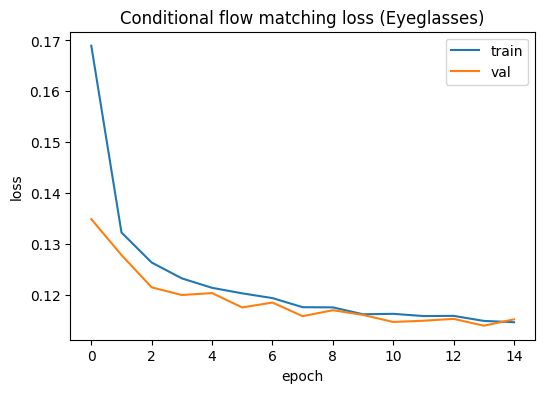

In [26]:
plt.figure(figsize=(6, 4))
plt.plot(cond_train_losses, label="train")
plt.plot(cond_val_losses, label="val")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.title(f"Conditional flow matching loss ({cfg.attribute_name})")
plt.show()

In [27]:
@torch.no_grad()
def sample_euler_conditional(model, y, n_samples=16, steps=100, size=64, device="cuda"):
    model.eval()
    x = torch.randn(n_samples, 3, size, size, device=device)
    dt = 1.0 / steps
    y = torch.full((n_samples,), y, device=device, dtype=torch.long)

    for i in range(steps):
        t = torch.full((n_samples,), i / steps, device=device)
        v = model(x, t, y)
        x = x + dt * v

    return x.clamp(-1, 1)


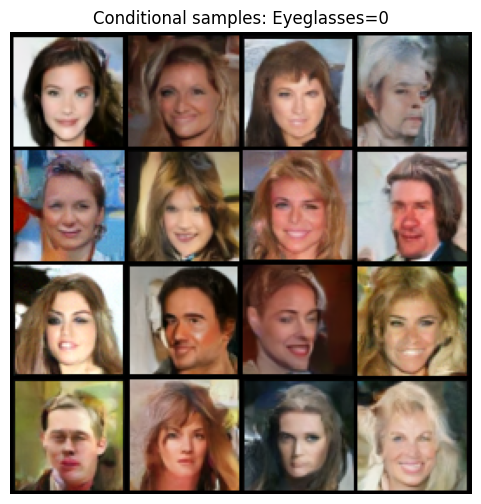

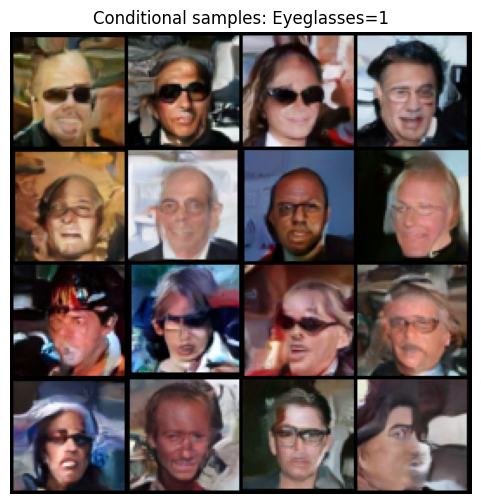

In [28]:
samples_no_glasses = sample_euler_conditional(
    cond_model, y=0, n_samples=16, steps=cfg.sample_steps, size=cfg.image_size, device=device
)
samples_with_glasses = sample_euler_conditional(
    cond_model, y=1, n_samples=16, steps=cfg.sample_steps, size=cfg.image_size, device=device
)

show_batch(samples_no_glasses, title=f"Conditional samples: {cfg.attribute_name}=0")
show_batch(samples_with_glasses, title=f"Conditional samples: {cfg.attribute_name}=1")

## Part B: Classifier guidance

Now we keep the unconditional flow model, and separately train a classifier
for the chosen CelebA attribute.

In [29]:
class SmallTimeAwareClassifier(nn.Module):
    def __init__(self, in_channels=3, base_ch=32):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, base_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(base_ch, base_ch * 2, 4, stride=2, padding=1)
        self.conv3 = nn.Conv2d(base_ch * 2, base_ch * 4, 4, stride=2, padding=1)
        self.conv4 = nn.Conv2d(base_ch * 4, base_ch * 4, 4, stride=2, padding=1)

        self.norm2 = nn.GroupNorm(8, base_ch * 2)
        self.norm3 = nn.GroupNorm(8, base_ch * 4)
        self.norm4 = nn.GroupNorm(8, base_ch * 4)

        self.time_mlp = nn.Sequential(
            nn.Linear(1, 128),
            nn.SiLU(),
            nn.Linear(128, base_ch * 4),
        )

        self.head = nn.Linear(base_ch * 4, 1)

    def forward(self, x, t):
        h = F.silu(self.conv1(x))
        h = F.silu(self.norm2(self.conv2(h)))
        h = F.silu(self.norm3(self.conv3(h)))
        h = F.silu(self.norm4(self.conv4(h)))
        h = h.mean(dim=(2, 3))

        t_feat = self.time_mlp(t[:, None])
        h = h + t_feat
        logits = self.head(F.silu(h)).squeeze(-1)
        return logits

In [30]:
classifier = SmallTimeAwareClassifier().to(device)
clf_optimizer = torch.optim.AdamW(classifier.parameters(), lr=cfg.lr, weight_decay=cfg.wd)

In [31]:
def classifier_loss(classifier, x1, y):
    b = x1.shape[0]
    x0 = torch.randn_like(x1)
    t = torch.rand(b, device=x1.device)
    xt = (1.0 - t[:, None, None, None]) * x0 + t[:, None, None, None] * x1

    logits = classifier(xt, t)
    return F.binary_cross_entropy_with_logits(logits, y.float())


In [32]:
def train_one_epoch_classifier(classifier, loader, optimizer, device, attr_idx):
    classifier.train()
    running = 0.0

    for x, attrs in loader:
        x = x.to(device, non_blocking=True)
        y = ((attrs[:, attr_idx] + 1) // 2).to(device).float()

        loss = classifier_loss(classifier, x, y)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        running += loss.item()

    return running / len(loader)

In [33]:
clf_epochs = 8
for epoch in range(clf_epochs):
    tr = train_one_epoch_classifier(classifier, train_loader, clf_optimizer, device, attr_idx)
    print(f"[classifier] epoch {epoch+1:02d} | train {tr:.4f}")

[classifier] epoch 01 | train 0.2286
[classifier] epoch 02 | train 0.1997
[classifier] epoch 03 | train 0.1877
[classifier] epoch 04 | train 0.1809
[classifier] epoch 05 | train 0.1733
[classifier] epoch 06 | train 0.1694
[classifier] epoch 07 | train 0.1655
[classifier] epoch 08 | train 0.1648


In [34]:
def classifier_guidance_gradient(classifier, x, t, target_y):
    x = x.detach().requires_grad_(True)
    logits = classifier(x, t)

    if target_y == 1:
        logp = F.logsigmoid(logits)
    else:
        logp = F.logsigmoid(-logits)

    grad = torch.autograd.grad(logp.sum(), x)[0]
    return grad


In [35]:
def sample_euler_classifier_guided(
    model,
    classifier,
    target_y=1,
    guidance_scale=2.0,
    n_samples=16,
    steps=100,
    size=64,
    device="cuda",
):
    model.eval()
    classifier.eval()

    x = torch.randn(n_samples, 3, size, size, device=device)
    dt = 1.0 / steps

    for i in range(steps):
        t = torch.full((n_samples,), i / steps, device=device)

        with torch.no_grad():
            v = model(x, t)

        grad = classifier_guidance_gradient(classifier, x, t, target_y)

        with torch.no_grad():
            x = x + dt * (v + guidance_scale * grad)

    return x.clamp(-1, 1)

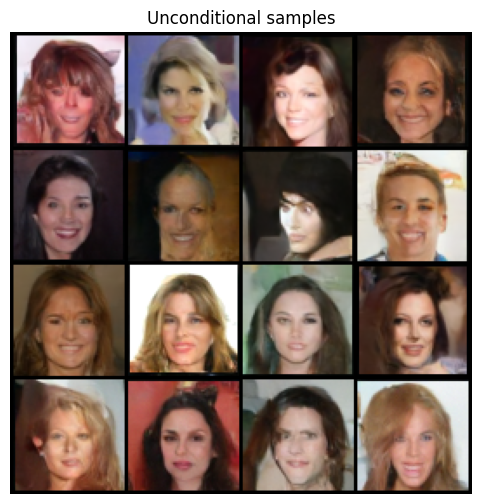

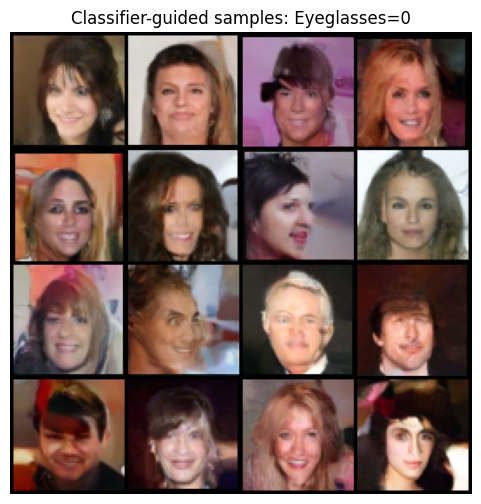

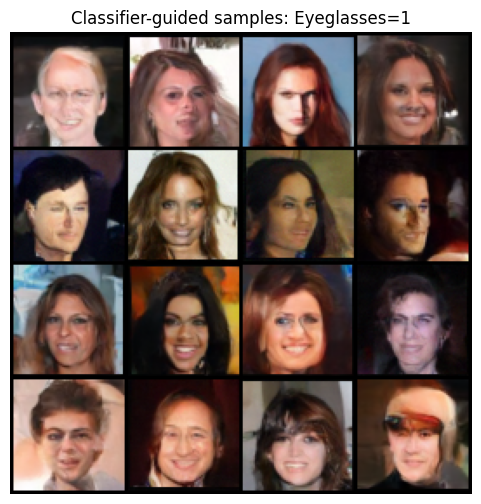

In [36]:
unguided = sample_euler(model, n_samples=16, steps=cfg.sample_steps, size=cfg.image_size, device=device)
guided_neg = sample_euler_classifier_guided(
    model, classifier, target_y=0, guidance_scale=2.0,
    n_samples=16, steps=cfg.sample_steps, size=cfg.image_size, device=device
)
guided_pos = sample_euler_classifier_guided(
    model, classifier, target_y=1, guidance_scale=2.0,
    n_samples=16, steps=cfg.sample_steps, size=cfg.image_size, device=device
)

show_batch(unguided, title="Unconditional samples")
show_batch(guided_neg, title=f"Classifier-guided samples: {cfg.attribute_name}=0")
show_batch(guided_pos, title=f"Classifier-guided samples: {cfg.attribute_name}=1")


In [37]:
save_dir = "./checkpoints_flow_matching_diffusers"
os.makedirs(save_dir, exist_ok=True)

torch.save(model.state_dict(), os.path.join(save_dir, "flow_model.pt"))
torch.save(cond_model.state_dict(), os.path.join(save_dir, "cond_flow_model.pt"))
torch.save(classifier.state_dict(), os.path.join(save_dir, "classifier.pt"))

print("saved checkpoints to", save_dir)

saved checkpoints to ./checkpoints_flow_matching_diffusers
